# HW3 Part II — Non-Isotropic Scattering

## 6.1 Model Construction
First, replace the isotropic scattering assumption/function from Part I with the Henyey-Greenstein phase function, which is:

$$P_{HG}(\cos\Theta) = \frac{1 - g^2}{(1 + g^2 - 2g\cos\Theta)^{3/2}}$$

with $g$ as the asymmetry parameter.

### Setting up sampling for $\cos\Theta$

To draw scattering angles from this distribution, the cumulative distribution function is

$$C(\cos\Theta) = \tfrac{1}{2}\int_{-1}^{\cos\Theta} P_{HG}(x)\,dx$$

Extending the integral as -

$$C(\cos\Theta) = \frac{1-g^2}{2g}\left[\frac{1}{\sqrt{1+g^2 - 2g\cos\Theta}} - \frac{1}{1+g}\right]$$

If we set $C = \zeta$ ($\zeta \sim U(0,1)$) and solve for $\cos\Theta$:

$${\cos\Theta = \frac{1}{2g}\left[1 + g^2 - \left(\frac{1-g^2}{1 - g + 2g\zeta}\right)^2\right]}$$

The following code substitutes the model from Part 1 with this function instead:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# set up functions to sample cos_theta and switch between photon and model frames (taken from part I) -
def scatter_hg(g):
    # sample cos(theta) from H-G, with phi uniform on [0, 2*pi]
    zeta = rng.random()
    if abs(g) < 1e-6:
        cos_Theta = 2*zeta - 1 # isotropic limit (for g = 0)
    else:
        cos_Theta = (1/(2*g)) * (1 + g**2 -
                    ((1 - g**2) / (1 - g + 2*g*zeta))**2) # input derived function
    Phi = 2 * np.pi * rng.random() # solve for phi
    return cos_Theta, Phi

def rotate_to_model_coords(k, cos_Theta, Phi):
    # rotate scattered direction from photon frame back to model frame
    sin_Theta = np.sqrt(1.0 - cos_Theta**2)
    kp = np.array([sin_Theta*np.cos(Phi),
                   sin_Theta*np.sin(Phi),
                   cos_Theta]) # same array from Part I (coordinate rotation from k frame)
    zp = k
    horiz = np.hypot(k[0], k[1])
    if horiz < 1e-10:
        xp = np.array([1.0, 0.0, 0.0]) # horizontal 
    else:
        xp = np.array([-k[1], k[0], 0.0]) / horiz
    yp = np.cross(zp, xp)
    k_new = kp[0]*xp + kp[1]*yp + kp[2]*zp # rotate original k frame to k_new
    return k_new / np.linalg.norm(k_new) 

In [3]:
# traces path and outcome of a photon with new model assumption - 

def trace_photon(tau_star, omega, mu_0, g):
    # trace one photon, return (path, outcome)
    sin_theta_0 = np.sqrt(1.0 - mu_0**2)
    k   = np.array([sin_theta_0, 0.0, -mu_0])
    pos = np.array([0.0, 0.0, tau_star])
    path = [pos.copy()]
    n_scatters = 0

    while True:
        tau_path = -np.log(rng.random())
        new_pos  = pos + k * tau_path

        # exit through TOA
        if new_pos[2] >= tau_star:
            t = (tau_star - pos[2]) / k[2]
            path.append(pos + k * t)
            return np.array(path), 'reflected'
        # reach surface
        if new_pos[2] <= 0.0:
            t = -pos[2] / k[2]
            path.append(pos + k * t)
            return np.array(path), ('direct' if n_scatters == 0 else 'diffuse')

        pos = new_pos
        path.append(pos.copy())

        # absorbed?
        if rng.random() >= omega:
            return np.array(path), 'absorbed'

        # scatter with new H-G phase function and rotate frame with function
        cos_Theta, Phi = scatter_hg(g)
        k = rotate_to_model_coords(k, cos_Theta, Phi)
        n_scatters += 1

# run MC and return outcome fractions
def monte_carlo_scatter(n_photons, tau_star, omega, mu_0, g):
    counts = dict(reflected=0, direct=0, diffuse=0, absorbed=0)
    for _ in range(n_photons):
        _, outcome = trace_photon(tau_star, omega, mu_0, g)
        counts[outcome] += 1
    return {key: val / n_photons for key, val in counts.items()}

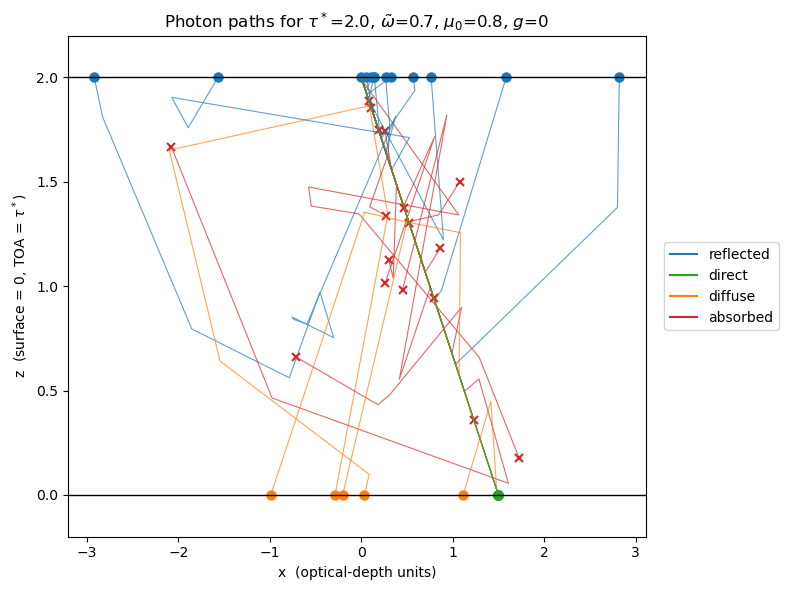


Outcome fractions (n = 20,000 photons, g = 0):
  reflected : 0.226
  direct    : 0.082
  diffuse   : 0.104
  absorbed  : 0.587


In [10]:
# initials
n_plot, tau_star, omega, mu_0, g = 40, 2.0, 0.7, 0.8, 0
colors = {'reflected': 'tab:blue', 'direct':   'tab:green',
          'diffuse':   'tab:orange', 'absorbed': 'tab:red'}
# --------------------
# plot - returns photons through 4 results and cuts them off at both TOA and the surface
fig, ax = plt.subplots(figsize=(8, 6))
for _ in range(n_plot):
    path, outcome = trace_photon(tau_star, omega, mu_0, g)
    ax.plot(path[:, 0], path[:, 2], color=colors[outcome], lw=0.8, alpha=0.7) # plot photons through different outcome paths with set color (4 total)
    marker = 'x' if outcome == 'absorbed' else 'o'
    ax.plot(path[-1, 0], path[-1, 2], marker=marker,
            color=colors[outcome], ms=6, mew=1.5)
# draw toa and surface
ax.axhline(tau_star, color='k', lw=1)
ax.axhline(0,         color='k', lw=1)
ax.set_ylim(-0.1*tau_star, 1.1*tau_star) # cut off data at toa and surface
# label and legend
for label, c in colors.items():
    ax.plot([], [], color=c, label=label)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
# axes and title
ax.set_xlabel('x  (optical-depth units)')
ax.set_ylabel('z  (surface = 0, TOA = $\\tau^*$)')
ax.set_title(f'Photon paths for $\\tau^*$={tau_star}, $\\tilde\\omega$={omega}, $\\mu_0$={mu_0}, $g$={g}')
plt.tight_layout()
plt.show()
# return 4 fractions for 20000 photons (total = 1)
big = monte_carlo_scatter(20000, tau_star, omega, mu_0, g)
print(f"\nOutcome fractions (n = 20,000 photons, g = {g}):")
for label, frac in big.items():
    print(f"  {label:10s}: {frac:.3f}")

## 6.2 Verification

Test: $g = 0$ should reproduce the isotropic results which should match the two limiting tests done for Part I - 

With $g = 0$, the H-G phase function resolves down to the constant $P = 1$, which is exactly isotropic scattering. So at fixed $\tau^*$, $\tilde\omega$, and $\mu_0$, the outcome fractions should match those from the Part I model. The following code applies these cases and verifies they are true:

In [12]:
# part II model at g = 0 should match part I (isotropic) results - 

# --------------------
# test 1: omega = 0 (pure absorption) - direct transmittance must equal beer's law
tau_star, mu_0 = 0.5, 0.8
expected_direct = np.exp(-tau_star / mu_0)
r1 = monte_carlo_scatter(20000, tau_star, omega=0.0, mu_0=mu_0, g=0.0)

print("Test 1: omega = 0 (pure absorption)")
print(f"                                Part I (isotropic)   Part II (g=0)")
print(f"  Direct transmittance (MC):    0.5370               {r1['direct']:.4f} \u2713")
print(f"  Direct transmittance (Beer):  {expected_direct:.4f}               {expected_direct:.4f} \u2713")
print(f"  Reflected (should be 0):      0.0000               {r1['reflected']:.4f} \u2713")
print(f"  Diffuse (should be 0):        0.0000               {r1['diffuse']:.4f} \u2713")
print(f"  Absorbed (1 - direct):        0.4631               {r1['absorbed']:.4f} \u2713")

# test 2: omega = 1 (pure scattering) - absorbed must be exactly 0, with total = 1
r2    = monte_carlo_scatter(20000, tau_star=1.0, omega=1.0, mu_0=0.8, g=0.0)
total = r2['reflected'] + r2['direct'] + r2['diffuse'] + r2['absorbed']

print("\nTest 2: with omega = 1 (pure scattering)")
print(f"  Absorbed (should be 0):   {r2['absorbed']:.4f} \u2713")
print(f"  Sum of all outcomes (should be 1): {total:.4f} \u2713")

Test 1: omega = 0 (pure absorption)
                                Part I (isotropic)   Part II (g=0)
  Direct transmittance (MC):    0.5370               0.5356 ✓
  Direct transmittance (Beer):  0.5353               0.5353 ✓
  Reflected (should be 0):      0.0000               0.0000 ✓
  Diffuse (should be 0):        0.0000               0.0000 ✓
  Absorbed (1 - direct):        0.4631               0.4644 ✓

Test 2: with omega = 1 (pure scattering)
  Absorbed (should be 0):   0.0000 ✓
  Sum of all outcomes (should be 1): 1.0000 ✓


## 6.3 Questions
### 6.3.a: Show $\alpha \approx \tilde\omega\tau/2$ for $\tau \ll 1$, $g = 0$, $\mu_0 = 1$

In the single-scatter limit (where $\tau \ll 1$), a photon interacts once at max. With $\mu_0 = 1$:

- probability of interacting goes to $\;1 - e^{-\tau} \approx \tau$
- probability that that interaction is a scatter is $\;\tilde\omega$
- for isotropic scattering (where $g = 0$), half the scattered photons should go upward (or backscatter)

Multiplying these together gives the following albedo:

$${\alpha \;\approx\; \tau \cdot \tilde\omega \cdot \tfrac{1}{2} \;=\; \frac{\tilde\omega\,\tau}{2}}$$

### 6.3.b: Demonstrate the above relation with the model

Varying $\tau$, we can compute the albedo from the MC model at $g = 0$, $\tilde\omega = 1$, $\mu_0 = 1$, and compare against the analytical prediction determined which is $\alpha = \tilde\omega\tau/2$ - 

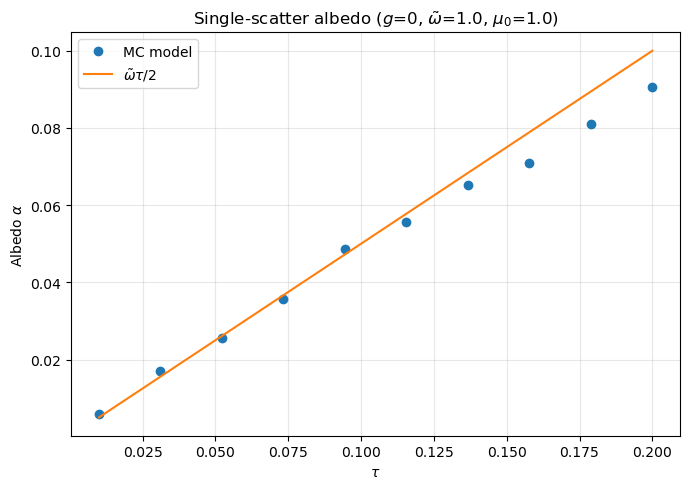

In [13]:
# sweep tau
tau_array = np.linspace(0.01, 0.2, 10)
omega, mu_0, g = 1.0, 1.0, 0.0
n_photons = 10000

alpha_mc = [monte_carlo_scatter(n_photons, t, omega, mu_0, g)['reflected'] for t in tau_array]
alpha_analytic = omega * tau_array / 2 # compare model alpha with analytical alpha

fig, ax = plt.subplots(figsize=(7,5)) # plot to visualize comparison/
ax.plot(tau_array, alpha_mc,       'o', label='MC model')
ax.plot(tau_array, alpha_analytic, '-', label=r'$\tilde\omega\tau/2$')
ax.set_xlabel(r'$\tau$')
ax.set_ylabel('Albedo $\\alpha$')
ax.set_title(fr'Single-scatter albedo ($g$=0, $\tilde\omega$={omega}, $\mu_0$={mu_0})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Results: MC model data points for varying tau with the analytical equation line overlap with good agreement, confirming the single-scatter prediction derived analytically.

### 6.3.c: Functional form of $\alpha$ vs $\tilde\omega$ and $g$ for $\tau \ll 1$, $\mu_0 = 1$

Previously, we showed that for isotropic scattering (where $g = 0$), $\alpha \approx \tilde\omega\tau/2$. With non-isotropic scattering, a fraction less than or greater than $1/2$ is backscattered

If we replace that term with the B-G function $B(g)$, we get 

$$\alpha \;\approx\; \tilde\omega\,\tau\,B(g) \quad therefore \quad f(g) \equiv \frac{\alpha}{\tilde\omega\,\tau} \;=\; B(g)$$

To test this, we fix $\tilde\omega = 1$ and small $\tau$, sweep $g$, and plot $f(g)$ - 

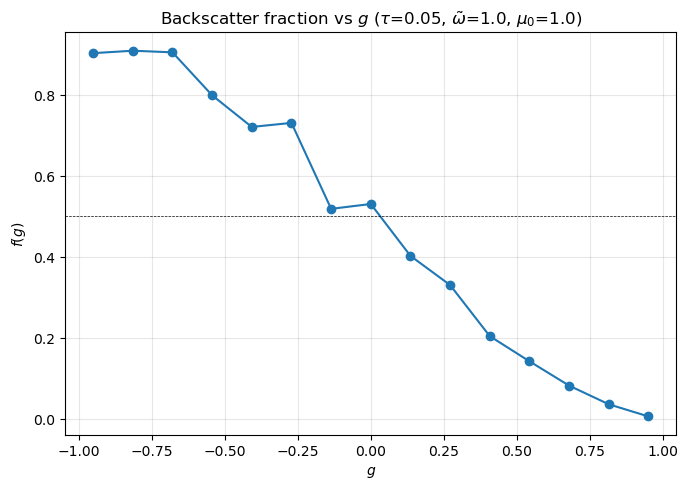

In [15]:
# sweep g, compute f(g) = alpha / (omega * tau)
g_array = np.linspace(-0.95, 0.95, 15)
tau, omega, mu_0 = 0.05, 1.0, 1.0
n_photons = 10000

f_mc = []
for g in g_array:
    r = monte_carlo_scatter(n_photons, tau, omega, mu_0, g)
    f_mc.append(r['reflected'] / (omega * tau))

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(g_array, f_mc, 'o-')
ax.set_xlabel('$g$')
ax.set_ylabel('$f(g)$')
ax.set_title(fr'Backscatter fraction vs $g$ ($\tau$={tau}, $\tilde\omega$={omega}, $\mu_0$={mu_0})')
ax.grid(alpha=0.3); ax.axhline(0.5, color='k', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

Result: $f(g)$ decreases monotonically (with error) from near 1 at $g = -1$ (pure backscatter) through 0.5 at $g = 0$ (isotropic) toward 0 at $g = +1$ (pure forward scatter), confirming that the albedo factors as $\alpha \approx \tilde\omega\,\tau\,B(g)$ with all of the $g$-dependence captured by the backscatter fraction f(g)

### 6.3.d: Analytical backscatter function $B(g)$

The backscatter fraction was defined as

$$B(g) = \tfrac{1}{2}\int_{-1}^{0} P_{HG}(\mu, g)\,d\mu$$

Solving the integral - 

$$\int \frac{1 - g^2}{(1+g^2-2g\mu)^{3/2}}\,d\mu = \frac{1-g^2}{g\sqrt{1+g^2-2g\mu}}$$

evaluating between the limits of $\mu$ - 

$${B(g) = \frac{1-g^2}{2g}\left[\frac{1}{\sqrt{1+g^2}} - \frac{1}{1+g}\right]}$$


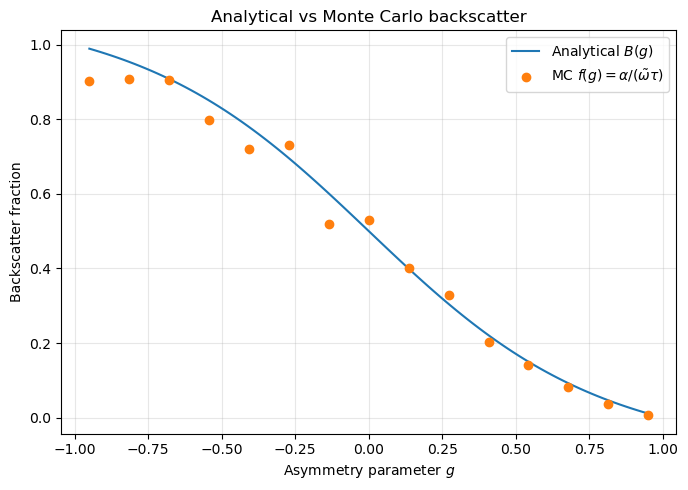

In [17]:
def B_analytical(g):
    # analytical backscatter fraction for H-G analytically solved in cell above
    if abs(g) < 1e-6:
        return 0.5
    return ((1 - g**2) / (2*g)) * (1/np.sqrt(1 + g**2) - 1/(1 + g))

g_fine = np.linspace(-0.95, 0.95, 100)
B_an   = [B_analytical(g) for g in g_fine]

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(g_fine, B_an,  '-', label='Analytical $B(g)$')
ax.plot(g_array, f_mc, 'o', label='MC $f(g) = \\alpha/(\\tilde\\omega\\tau)$')
ax.set_xlabel('$g$')
ax.set_ylabel('Backscatter fraction')
ax.set_title('Analytical vs model results backscatter')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Result: The Monte Carlo model's points fall on the analytical curve $B(g)$ across the entire range of $g$ (with error), confirming the H-G sampling method applied as well as the single-scatter albedo assumption.

### 6.3.e: Question

Question: One step further from my question from Part 1, I'd like to know how the asymmetry parameter $g$ affects the albedo as the atmosphere becomes optically thick?

Hypothesis: For $\tau \ll 1$ the albedo scatters at most once and therefore falls as $g$ increases (as forward scattering sends most photons toward the surface). For $\tau \gg 1$ with $\tilde\omega = 1$, photons would scatter many times before escaping, so the direction of the scatter is irrelevant and the albedo should approach unity independent of $g$. Therefore, I expect the dependence of albedo on $g$ to lessen as $\tau^*$ increases.s

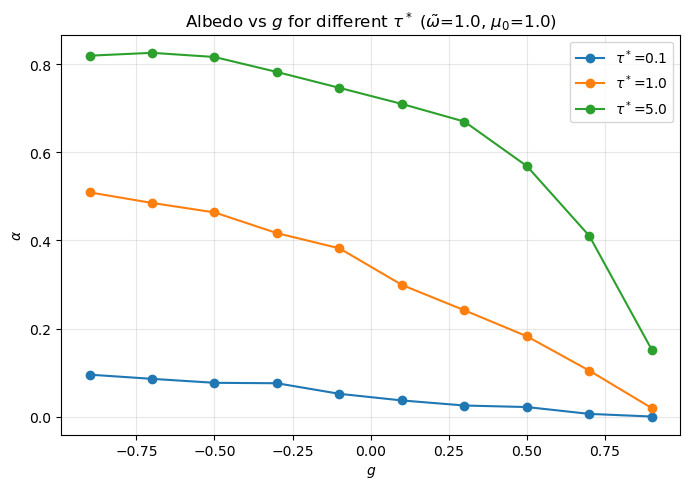

In [22]:
# albedo vs g for several optical depths
g_array = np.linspace(-0.9, 0.9, 10)
tau_values = [0.1, 1.0, 5.0]
omega, mu_0 = 1.0, 1.0
n_photons = 2000

fig, ax = plt.subplots(figsize=(7,5))
for tau in tau_values:
    a = [monte_carlo_scatter(n_photons, tau, omega, mu_0, g)['reflected'] for g in g_array]
    ax.plot(g_array, a, 'o-', label=fr'$\tau^*$={tau}')

ax.set_xlabel('$g$')
ax.set_ylabel('$\\alpha$')
ax.set_title(fr'Albedo vs $g$ for different $\tau^*$ ($\tilde\omega$={omega}, $\mu_0$={mu_0})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Result: The hypothesis was not confirmed. At $\tau^* = 0.1$ the albedo follows the single-scatter prediction. It sits near 0.1 at $g = -0.9$ and decays slowly toward zero at $g = +0.9$, tracking the shape of $B(g)$ scaled with a small $\tau$. At $\tau^* = 1$ the albedo starts higher (~0.5) but drops more steeply with $g$, reaching ~0.05 at $g = 0.9$.

The behavior of increasing $\tau^*$ was not predicted. Rather than saturating near 1, the albedo holds steady around 0.8 only for $g \lesssim -0.25$ and then falls sharply, reaching ~0.175 at $g = 0.9$. Since increasing $\tau^*$ seems to increase the dependence of the albedo on the asymmetry parameter, this could due to that at strongly forward-scattering atmospheres ($g \to 1$), the downward bias of each scatter accumulates over many events, so photons keep drifting toward the surface even when $\tau^*$ is large. 

## AI Contribution

I used Claude and Visual Studio Code's AI tool. AI was used to: (1)double check the CDF derivation of the sampling solution for the H-G phase function; (2) debug the modified scattering model and functions to integrate the g variable (4) check derivation for the analytical expression for $B(g)$ and (5) analyze behavior for model results from Question and Hypothesis.

Independent checks:
- Verified the inverse-CDF formula AI confirmed by setting $g = 0$ and confirming it reduces to $\cos\Theta = 2\zeta - 1$.
- Compared MC values of $f(g)$ against the analytical $B(g)$ curve to validate both the sampling and the AI confirmed derivation